# Projet 4 : Modélisation d'Indicateurs Avancés

**Auteur :** ISLEYEN Volkan  
**Statut :** Étudiant L3 Économie & Gestion | Candidat Master Finance de Marché  
**Sujet :** Programmation d'un module d'analyse technique complet (Tendance, Momentum, Volume)  
**Stack :** Python 3.12 · pandas · numpy · matplotlib · yfinance

---

## Contexte du Projet

Dans le cadre de ma préparation pour le **Master Finance de Marché**, ce projet développe un outil d'aide à la décision quantitatif. Plutôt que de se limiter à l'observation brute des prix, l'enjeu est de construire un script Python capable de décrypter la microstructure des mouvements de marché en combinant plusieurs familles d'indicateurs.

## Indicateurs Modélisés

| Indicateur | Famille | Rôle |
|-----------|---------|------|
| **RSI** — Relative Strength Index | Momentum | Détection surachat / survente |
| **MACD** — Moving Average Convergence Divergence | Tendance | Suivi de momentum et signaux d'entrée/sortie |
| **OBV** — On-Balance Volume | Volume | Pression acheteurs / vendeurs |
| **CMF** — Chaikin Money Flow | Volume | Flux monétaire et accumulation/distribution |

## Méthodologie

Chaque indicateur est calculé manuellement à partir des formules mathématiques fondamentales, sans recourir à des librairies tierces (comme `ta-lib`), afin de démontrer la maîtrise des concepts sous-jacents.

> **Prérequis :** `pip install yfinance pandas numpy matplotlib`

In [1]:
# ── Imports & configuration ─────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec

TICKER = 'AAPL'
START  = '2020-01-01'
END    = '2024-12-31'

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.size'] = 10

print(f"Actif   : {TICKER}")
print(f"Période : {START} → {END}")

Actif   : AAPL
Période : 2020-01-01 → 2024-12-31


## 1. Importation des données

In [2]:
apple = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
apple.columns = [col[0] if isinstance(col, tuple) else col for col in apple.columns]
apple.dropna(inplace=True)

print(f"Jours de trading : {len(apple)}")
print(f"Prix départ      : ${apple['Close'].iloc[0]:.2f}")
print(f"Prix fin         : ${apple['Close'].iloc[-1]:.2f}")
apple.head()

Jours de trading : 1257
Prix départ      : $72.40
Prix fin         : $250.83


,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2020-01-06,72.267929,72.306499,70.568503,70.819201,118387200
2020-01-07,71.928047,72.533087,71.708687,72.277571,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


## 2. RSI — Relative Strength Index

Le RSI mesure la **vitesse et l'amplitude** des variations de prix. Il oscille entre 0 et 100 :

$$RSI = 100 - \frac{100}{1 + RS} \quad \text{avec} \quad RS = \frac{\text{Moyenne des gains sur } n \text{ périodes}}{\text{Moyenne des pertes sur } n \text{ périodes}}$$

| Niveau | Interprétation |
|--------|----------------|
| RSI > 70 | Surachat — possible repli |
| RSI < 30 | Survente — possible rebond |
| RSI ≈ 50 | Marché neutre |

RSI actuel   : 60.2
RSI moyen    : 54.4
Jours > 70   : 137 (11.0%)
Jours < 30   : 18 (1.4%)


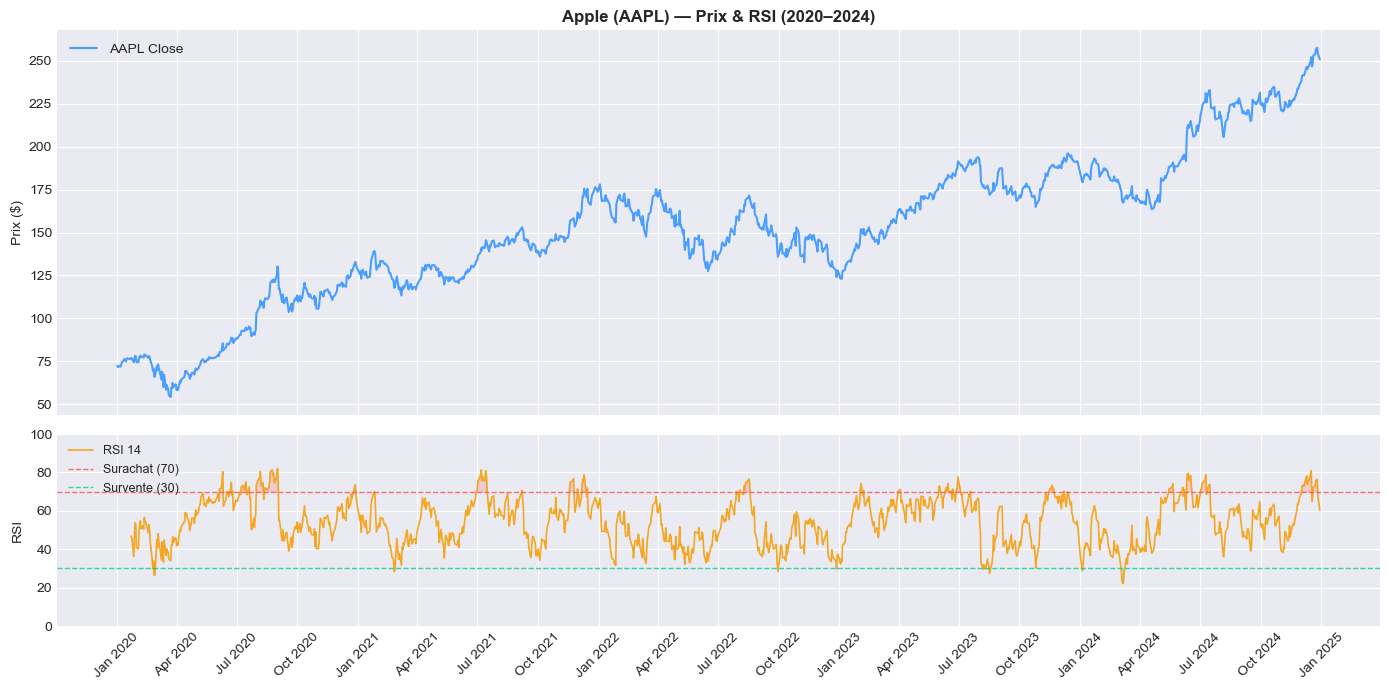

In [3]:
def calcul_rsi(serie, periode=14):
    """Calcule le RSI selon la méthode de Wilder (EMA lissée)."""
    delta  = serie.diff()
    gains  = delta.clip(lower=0)
    pertes = (-delta).clip(lower=0)
    avg_gain = gains.ewm(alpha=1/periode, min_periods=periode, adjust=False).mean()
    avg_loss = pertes.ewm(alpha=1/periode, min_periods=periode, adjust=False).mean()
    rs  = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

apple['RSI'] = calcul_rsi(apple['Close'])

# Statistiques
rsi = apple['RSI'].dropna()
print(f"RSI actuel   : {rsi.iloc[-1]:.1f}")
print(f"RSI moyen    : {rsi.mean():.1f}")
print(f"Jours > 70   : {(rsi > 70).sum()} ({(rsi > 70).mean()*100:.1f}%)")
print(f"Jours < 30   : {(rsi < 30).sum()} ({(rsi < 30).mean()*100:.1f}%)")

# Visualisation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(apple.index, apple['Close'], color='#4a9eff', linewidth=1.5, label='AAPL Close')
ax1.set_title('Apple (AAPL) — Prix & RSI (2020–2024)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Prix ($)')
ax1.legend()

ax2.plot(apple.index, apple['RSI'], color='#f5a623', linewidth=1.2, label='RSI 14')
ax2.axhline(70, color='#ff4d4d', linestyle='--', linewidth=1, alpha=0.8, label='Surachat (70)')
ax2.axhline(30, color='#00d084', linestyle='--', linewidth=1, alpha=0.8, label='Survente (30)')
ax2.axhline(50, color='white',   linestyle=':',  linewidth=0.6, alpha=0.4)
ax2.fill_between(apple.index, apple['RSI'], 70, where=(apple['RSI'] >= 70), alpha=0.2, color='#ff4d4d')
ax2.fill_between(apple.index, apple['RSI'], 30, where=(apple['RSI'] <= 30), alpha=0.2, color='#00d084')
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. MACD — Moving Average Convergence Divergence

Le MACD mesure la **dynamique de tendance** en comparant deux EMA :

$$MACD = EMA_{12}(P) - EMA_{26}(P)$$
$$Signal = EMA_{9}(MACD)$$
$$Histogramme = MACD - Signal$$

- **Croisement MACD > Signal** → signal d'achat
- **Croisement MACD < Signal** → signal de vente
- **Histogramme positif/négatif** → force du momentum

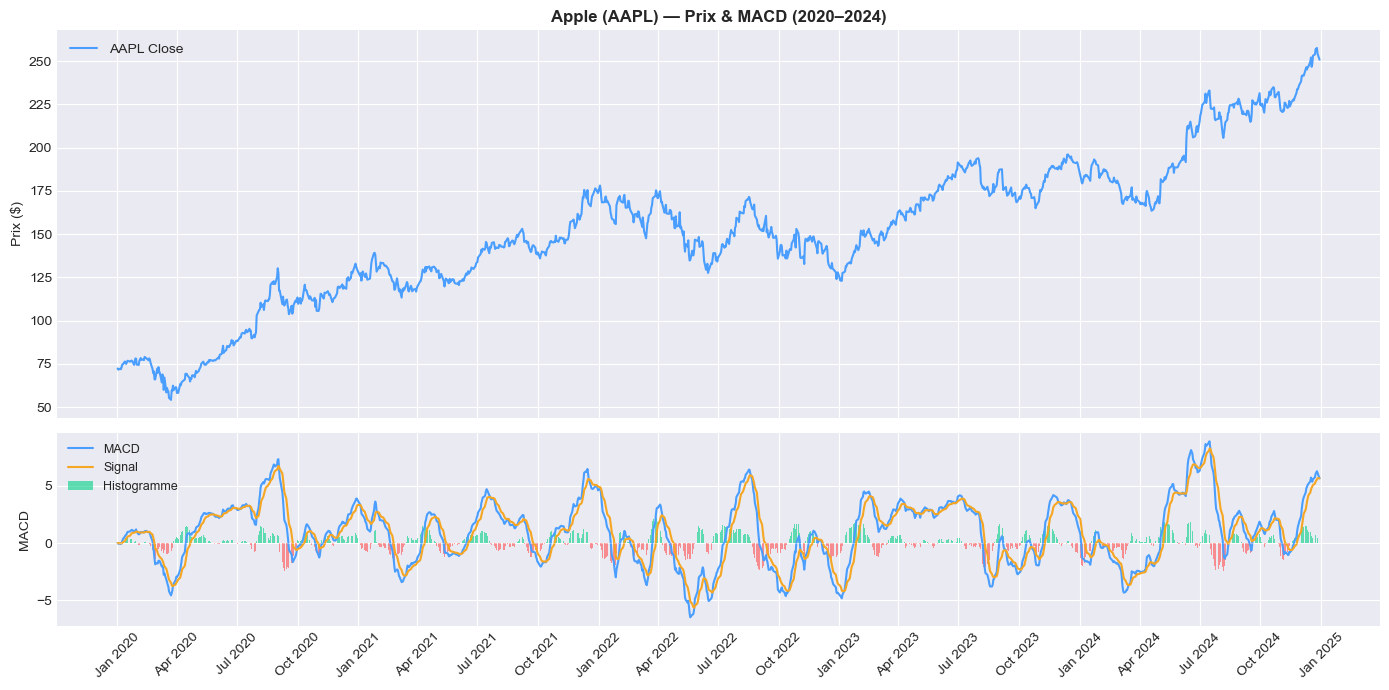

In [4]:
# Calcul du MACD
ema12 = apple['Close'].ewm(span=12, adjust=False).mean()
ema26 = apple['Close'].ewm(span=26, adjust=False).mean()
apple['MACD']        = ema12 - ema26
apple['MACD_Signal'] = apple['MACD'].ewm(span=9, adjust=False).mean()
apple['MACD_Hist']   = apple['MACD'] - apple['MACD_Signal']

# Visualisation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(apple.index, apple['Close'], color='#4a9eff', linewidth=1.5, label='AAPL Close')
ax1.set_title('Apple (AAPL) — Prix & MACD (2020–2024)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Prix ($)')
ax1.legend()

ax2.plot(apple.index, apple['MACD'],        color='#4a9eff', linewidth=1.5, label='MACD')
ax2.plot(apple.index, apple['MACD_Signal'], color='#f5a623', linewidth=1.5, label='Signal')
colors_hist = ['#00d084' if v >= 0 else '#ff4d4d' for v in apple['MACD_Hist']]
ax2.bar(apple.index, apple['MACD_Hist'], color=colors_hist, alpha=0.6, width=1, label='Histogramme')
ax2.axhline(0, color='white', linewidth=0.6, linestyle='--', alpha=0.4)
ax2.set_ylabel('MACD')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. OBV — On-Balance Volume

L'OBV cumule les volumes selon la direction du cours :

$$OBV_t = \begin{cases} OBV_{t-1} + Volume_t & \text{si } Close_t > Close_{t-1} \\ OBV_{t-1} - Volume_t & \text{si } Close_t < Close_{t-1} \\ OBV_{t-1} & \text{si } Close_t = Close_{t-1} \end{cases}$$

- **OBV croissant** → accumulation (pression acheteuse)
- **OBV décroissant** → distribution (pression vendeuse)
- **Divergence OBV/Prix** → signal de retournement potentiel

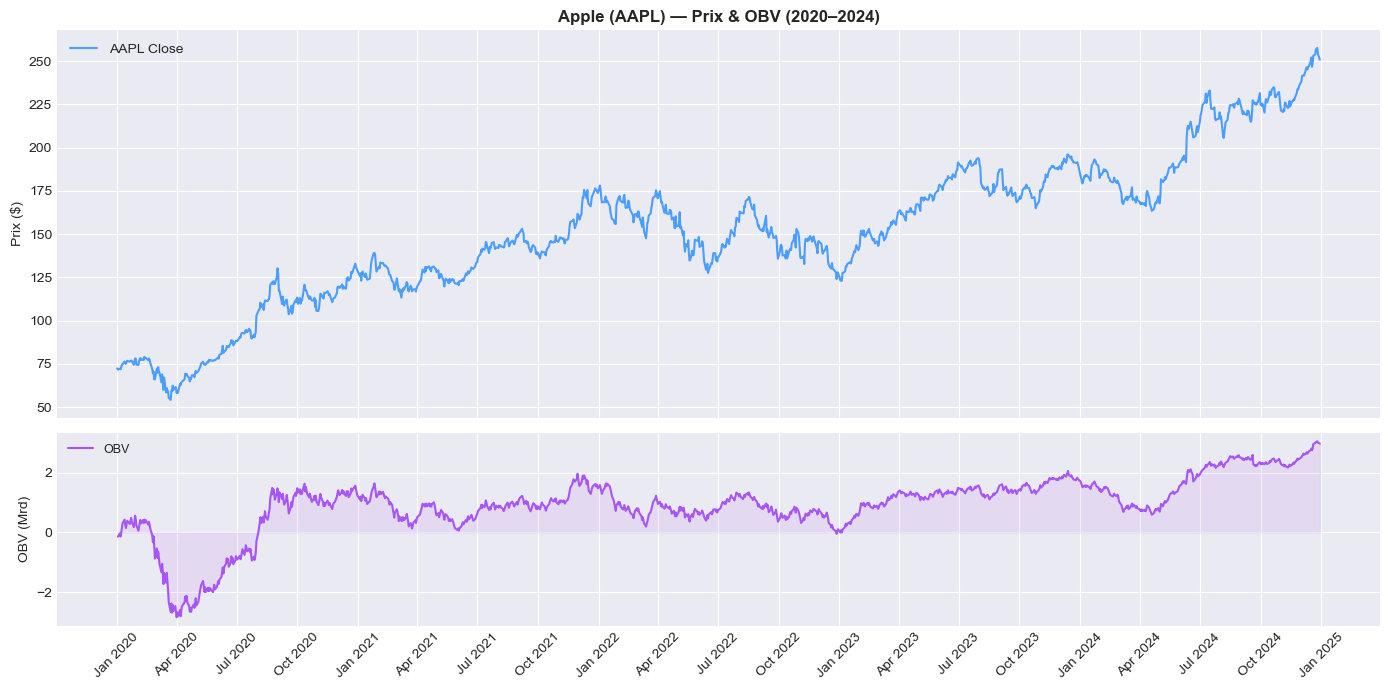

In [5]:
# Calcul de l'OBV
direction = np.sign(apple['Close'].diff())
apple['OBV'] = (direction * apple['Volume']).cumsum()

# Visualisation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(apple.index, apple['Close'], color='#4a9eff', linewidth=1.5, label='AAPL Close')
ax1.set_title('Apple (AAPL) — Prix & OBV (2020–2024)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Prix ($)')
ax1.legend()

ax2.plot(apple.index, apple['OBV'] / 1e9, color='#a855f7', linewidth=1.5, label='OBV')
ax2.fill_between(apple.index, apple['OBV'] / 1e9, alpha=0.1, color='#a855f7')
ax2.set_ylabel('OBV (Mrd)')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. CMF — Chaikin Money Flow

Le CMF mesure le **flux monétaire** sur une fenêtre glissante en combinant prix et volume :

$$CLV_t = \frac{(Close_t - Low_t) - (High_t - Close_t)}{High_t - Low_t}$$
$$MFV_t = CLV_t \times Volume_t$$
$$CMF_{20} = \frac{\sum_{i=1}^{20} MFV_i}{\sum_{i=1}^{20} Volume_i}$$

| CMF | Interprétation |
|-----|----------------|
| CMF > 0 | Pression acheteuse → tendance haussière |
| CMF < 0 | Pression vendeuse → tendance baissière |
| Divergence avec le prix | Possible retournement |

CMF actuel  : 0.326
CMF moyen   : 0.058
Jours > 0   : 798 (64.5%) — pression acheteuse
Jours < 0   : 440 (35.5%) — pression vendeuse


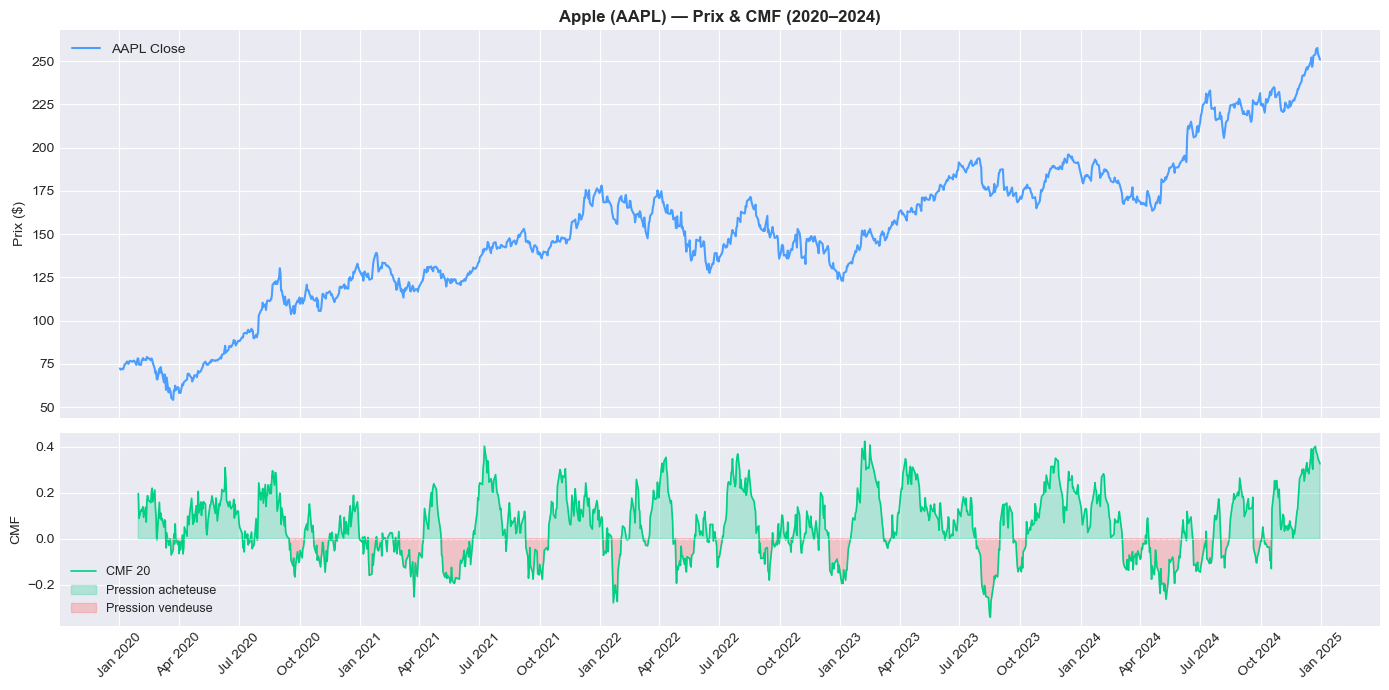

In [6]:
# Calcul du CMF
clv = ((apple['Close'] - apple['Low']) - (apple['High'] - apple['Close'])) / (apple['High'] - apple['Low'])
mfv = clv * apple['Volume']
apple['CMF'] = mfv.rolling(window=20).sum() / apple['Volume'].rolling(window=20).sum()

# Statistiques
cmf = apple['CMF'].dropna()
print(f"CMF actuel  : {cmf.iloc[-1]:.3f}")
print(f"CMF moyen   : {cmf.mean():.3f}")
print(f"Jours > 0   : {(cmf > 0).sum()} ({(cmf > 0).mean()*100:.1f}%) — pression acheteuse")
print(f"Jours < 0   : {(cmf < 0).sum()} ({(cmf < 0).mean()*100:.1f}%) — pression vendeuse")

# Visualisation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(apple.index, apple['Close'], color='#4a9eff', linewidth=1.5, label='AAPL Close')
ax1.set_title('Apple (AAPL) — Prix & CMF (2020–2024)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Prix ($)')
ax1.legend()

ax2.plot(apple.index, apple['CMF'], color='#00d084', linewidth=1.2, label='CMF 20')
ax2.fill_between(apple.index, apple['CMF'], 0,
                 where=(apple['CMF'] >= 0), alpha=0.25, color='#00d084', label='Pression acheteuse')
ax2.fill_between(apple.index, apple['CMF'], 0,
                 where=(apple['CMF'] < 0),  alpha=0.25, color='#ff4d4d', label='Pression vendeuse')
ax2.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax2.set_ylabel('CMF')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Tableau de bord complet — Les 4 indicateurs

Vue synthétique combinant les 4 indicateurs sur la même période pour faciliter la lecture croisée des signaux.

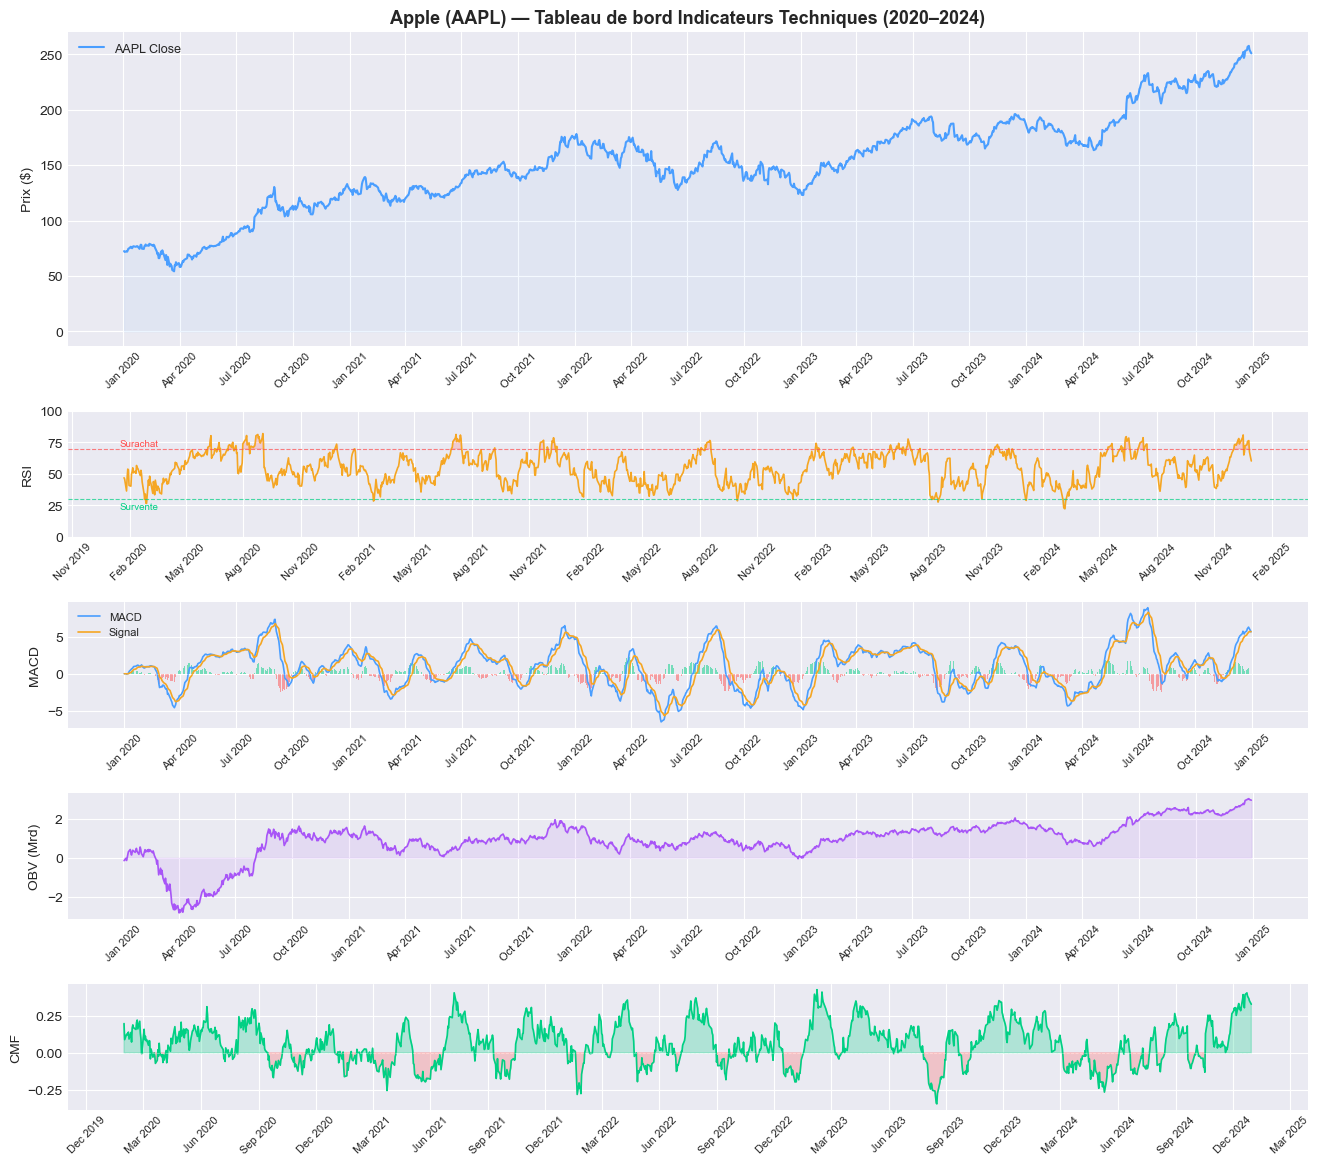

In [7]:
fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(5, 1, hspace=0.4, height_ratios=[2.5, 1, 1, 1, 1])

# Panel 1 : Prix
ax1 = fig.add_subplot(gs[0])
ax1.plot(apple.index, apple['Close'], color='#4a9eff', linewidth=1.5, label='AAPL Close')
ax1.fill_between(apple.index, apple['Close'], alpha=0.06, color='#4a9eff')
ax1.set_title('Apple (AAPL) — Tableau de bord Indicateurs Techniques (2020–2024)',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Prix ($)')
ax1.legend(fontsize=9)

# Panel 2 : RSI
ax2 = fig.add_subplot(gs[1])
ax2.plot(apple.index, apple['RSI'], color='#f5a623', linewidth=1.2)
ax2.axhline(70, color='#ff4d4d', linestyle='--', linewidth=0.8, alpha=0.7)
ax2.axhline(30, color='#00d084', linestyle='--', linewidth=0.8, alpha=0.7)
ax2.fill_between(apple.index, apple['RSI'], 70, where=(apple['RSI'] >= 70), alpha=0.2, color='#ff4d4d')
ax2.fill_between(apple.index, apple['RSI'], 30, where=(apple['RSI'] <= 30), alpha=0.2, color='#00d084')
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.text(apple.index[10], 72, 'Surachat', fontsize=7, color='#ff4d4d')
ax2.text(apple.index[10], 22, 'Survente', fontsize=7, color='#00d084')

# Panel 3 : MACD
ax3 = fig.add_subplot(gs[2])
ax3.plot(apple.index, apple['MACD'],        color='#4a9eff', linewidth=1.2, label='MACD')
ax3.plot(apple.index, apple['MACD_Signal'], color='#f5a623', linewidth=1.2, label='Signal')
colors_hist = ['#00d084' if v >= 0 else '#ff4d4d' for v in apple['MACD_Hist']]
ax3.bar(apple.index, apple['MACD_Hist'], color=colors_hist, alpha=0.5, width=1)
ax3.axhline(0, color='white', linewidth=0.5, linestyle='--', alpha=0.4)
ax3.set_ylabel('MACD')
ax3.legend(fontsize=8, loc='upper left')

# Panel 4 : OBV
ax4 = fig.add_subplot(gs[3])
ax4.plot(apple.index, apple['OBV'] / 1e9, color='#a855f7', linewidth=1.2)
ax4.fill_between(apple.index, apple['OBV'] / 1e9, alpha=0.1, color='#a855f7')
ax4.set_ylabel('OBV (Mrd)')

# Panel 5 : CMF
ax5 = fig.add_subplot(gs[4])
ax5.plot(apple.index, apple['CMF'], color='#00d084', linewidth=1.2)
ax5.fill_between(apple.index, apple['CMF'], 0,
                 where=(apple['CMF'] >= 0), alpha=0.25, color='#00d084')
ax5.fill_between(apple.index, apple['CMF'], 0,
                 where=(apple['CMF'] < 0),  alpha=0.25, color='#ff4d4d')
ax5.axhline(0, color='white', linewidth=0.6, linestyle='--', alpha=0.4)
ax5.set_ylabel('CMF')

for ax in [ax1, ax2, ax3, ax4, ax5]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, fontsize=8)

plt.tight_layout()
plt.show()

## Conclusion

Ce projet a implémenté manuellement quatre indicateurs techniques fondamentaux sur Apple (AAPL) sur la période 2020–2024.

**Synthèse des indicateurs :**

- Le **RSI** confirme que AAPL a traversé plusieurs phases de surachat (notamment en 2021 et 2023) et de rares phases de survente, reflétant la tendance haussière structurelle de l'action
- Le **MACD** identifie clairement les changements de momentum — les croisements haussiers de 2020 et 2023 ont précédé des rallyes significatifs
- L'**OBV** croissant sur l'ensemble de la période confirme une pression acheteuse dominante, cohérente avec la hausse des cours
- Le **CMF** révèle des périodes d'accumulation (CMF > 0 persistant) et de distribution, particulièrement visibles lors de la correction de 2022

**Limite et perspective :** Aucun indicateur ne doit être utilisé isolément. La vraie valeur de ces outils réside dans leur **lecture croisée** : un signal RSI de survente confirmé par un CMF positif et un MACD en croisement haussier constitue un signal bien plus fiable qu'un indicateur seul.

**Prochaine étape →** Projet 5 : Backtesting avec la librairie Backtrader